# Benchmark Results Analysis
This notebook reads the raw benchmark output from `results/benchmark_results.csv` and generates high-resolution academic box plots to compare the latency of different storage approaches.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_FILE = Path("results/benchmark_results.csv")

# Load data
df = pd.read_csv(RESULTS_FILE)
df["elapsed_seconds"] = pd.to_numeric(df["elapsed_seconds"], errors="coerce")

# Set an academic, clean theme for the plots
sns.set_theme(style="whitegrid", palette="deep")
phases = df["phase"].unique()

print("Data loaded successfully! Found phases:", phases)

Data loaded successfully! Found phases: ['write' 'query' 'read']


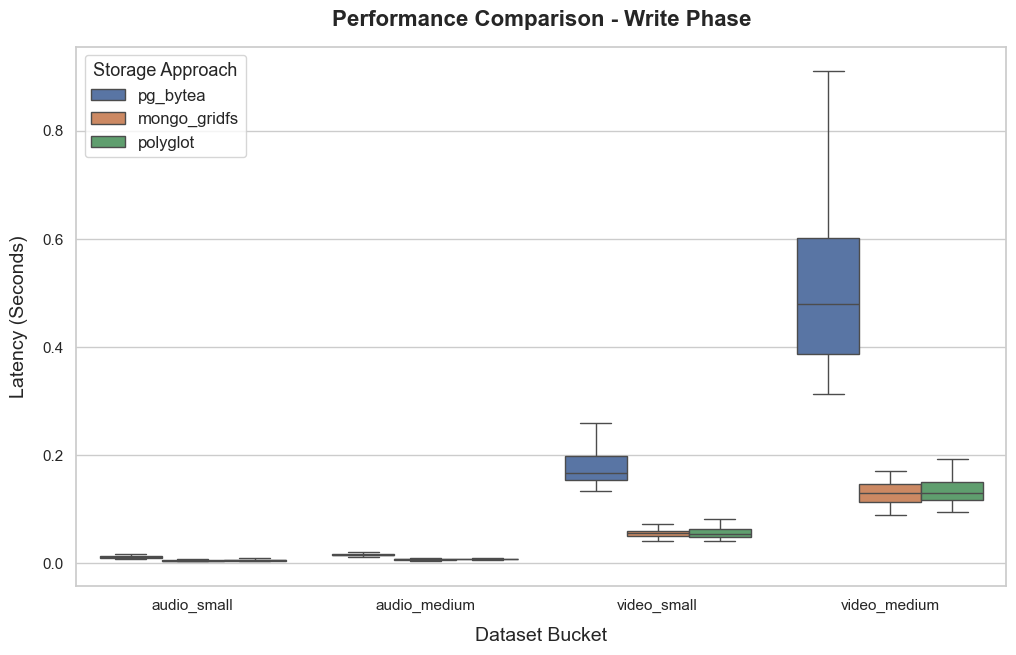

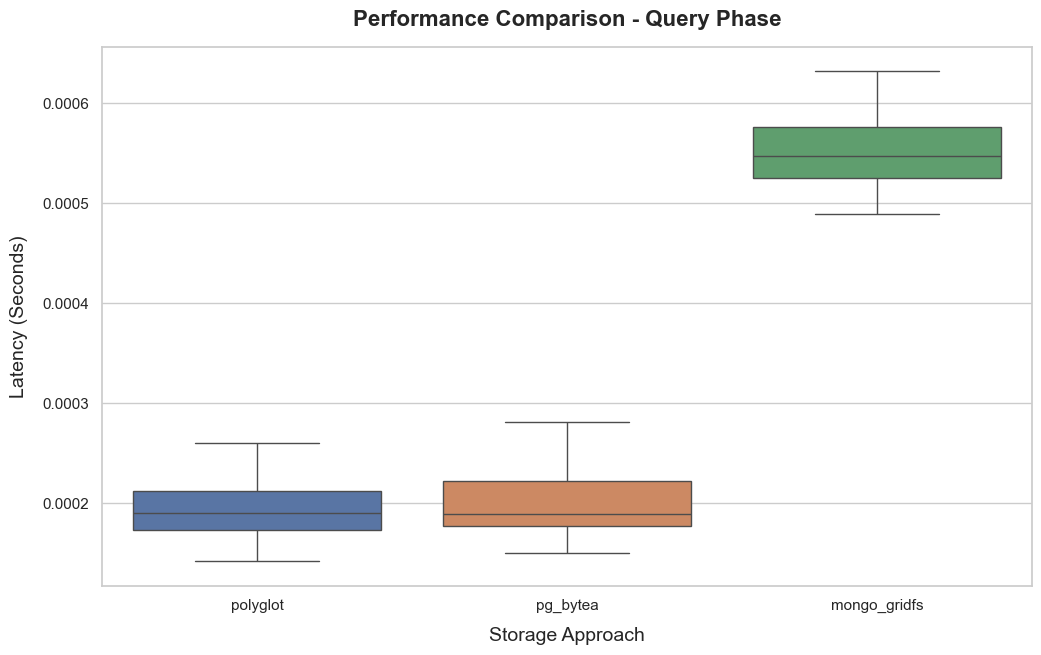

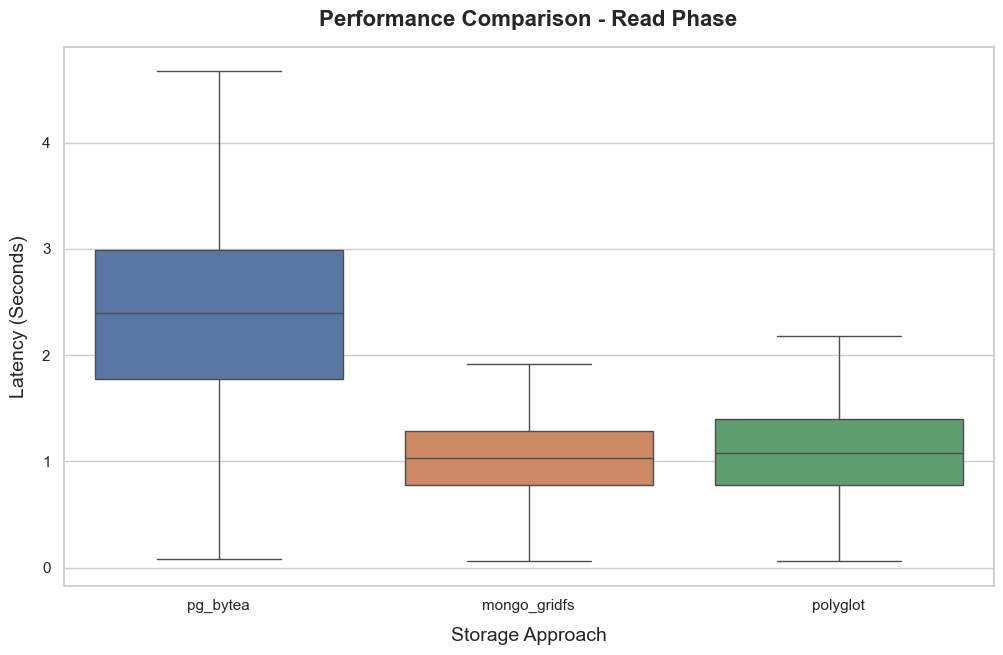

In [5]:
for phase in phases:
    phase_df = df[df["phase"] == phase]
    
    # Create a new figure
    plt.figure(figsize=(12, 7))
    
    # Check if the 'bucket' column has values for this phase
    if phase_df["bucket"].notna().any():
        ax = sns.boxplot(
            data=phase_df, 
            x="bucket", 
            y="elapsed_seconds", 
            hue="approach",
            showfliers=False # Hide extreme outliers so the main boxes are visible
        )
        plt.xlabel("Dataset Bucket", fontsize=14, labelpad=10)
        plt.legend(title="Storage Approach", title_fontsize='13', fontsize='12', loc='upper left')
    else:
        # Query and Read phases do not have buckets
        ax = sns.boxplot(
            data=phase_df, 
            x="approach", 
            y="elapsed_seconds", 
            hue="approach",
            showfliers=False
        )
        plt.xlabel("Storage Approach", fontsize=14, labelpad=10)
        
    # Formatting titles and labels
    phase_title = phase.capitalize().replace('_', ' ')
    plt.title(f"Performance Comparison - {phase_title} Phase", fontsize=16, fontweight='bold', pad=15)
    plt.ylabel("Latency (Seconds)", fontsize=14, labelpad=10)
    
    #plt.tight_layout()
    
    # Display the plot in the notebook
    plt.show()